

## CPSC 4970 M2 Homework - Jonathan Braun

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude         

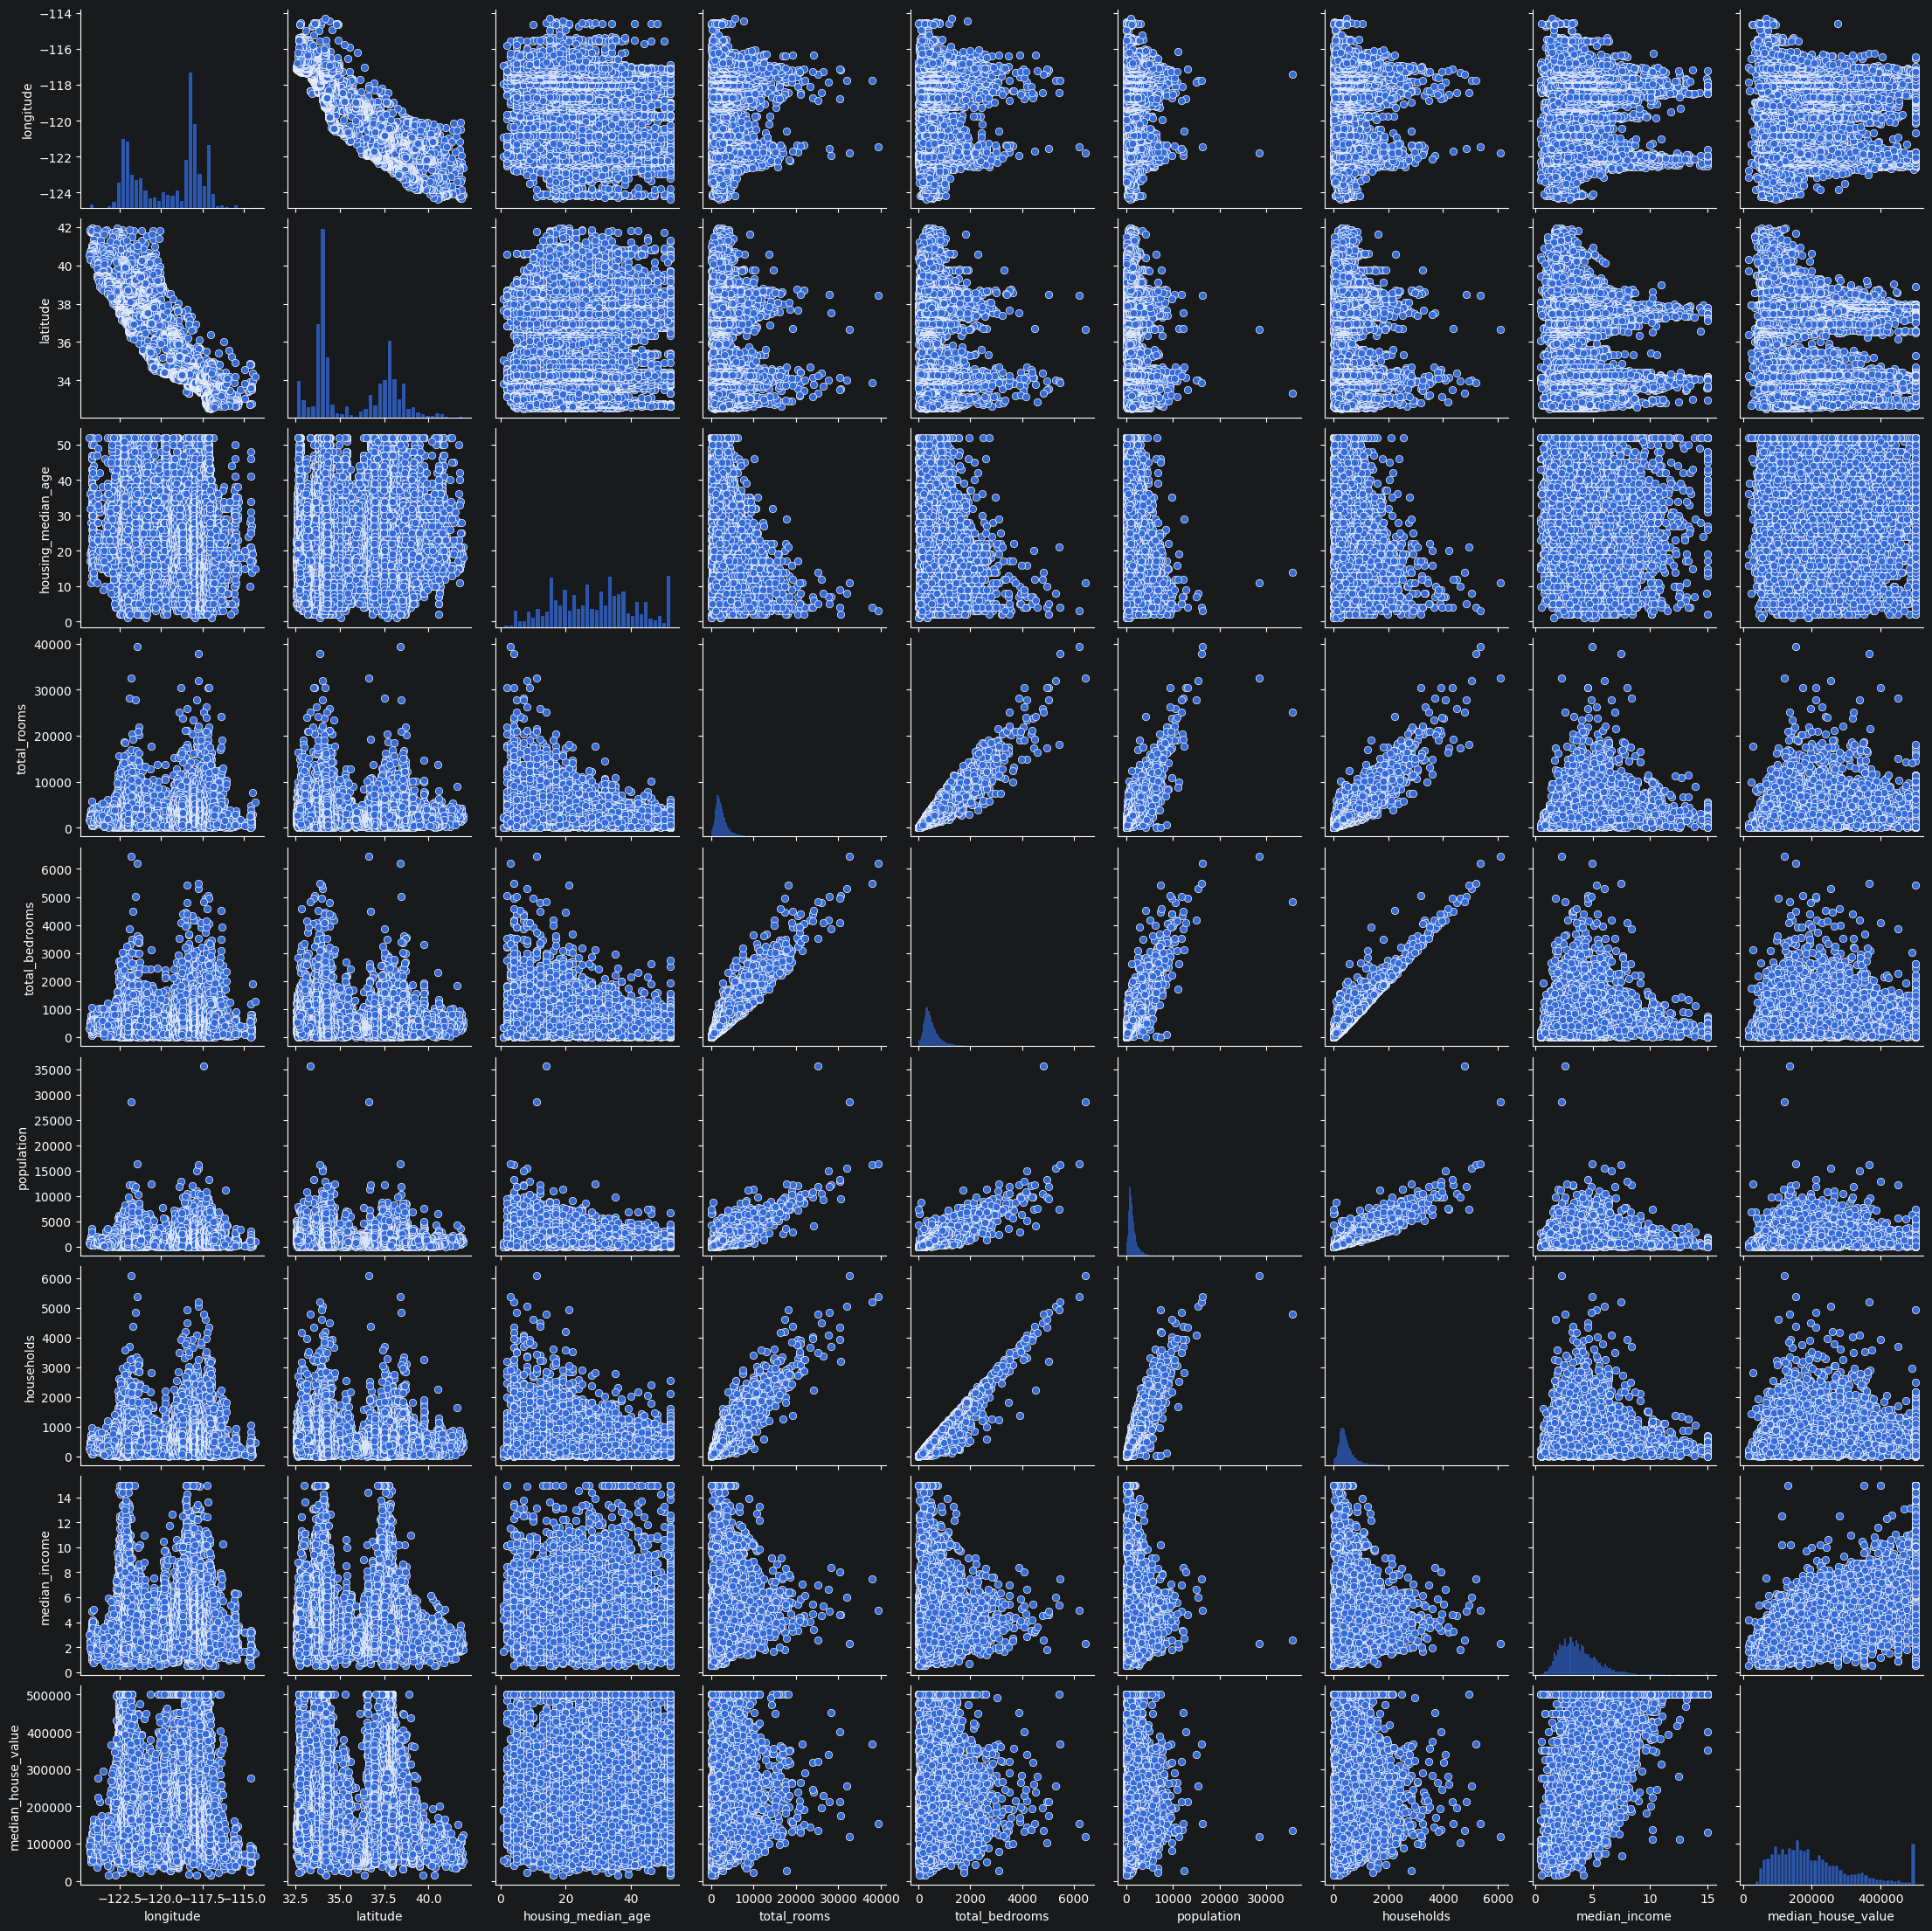

In [2]:
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"

housing = pd.read_csv(url)

housing.info()
housing.head()

housing = housing.drop(columns=["ocean_proximity"], errors="ignore")
housing.info()

sns.pairplot(housing)
plt.show()

The pair grid shows relationships between the numerical columns. Some variables show skewed distributions and several outliers, but there are no obvious invalid patterns that prevent continuing with the regression models.

In [3]:
x = housing.drop(columns=["median_house_value"])
y = housing["median_house_value"]

print("x type:", type(x))
print("y type:", type(y))

print("x shape:", x.shape)
print("y shape:", y.shape)

x type: <class 'pandas.DataFrame'>
y type: <class 'pandas.Series'>
x shape: (20640, 8)
y shape: (20640,)


In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("x_train type:", type(x_train))
print("x_test type:", type(x_test))
print("y_train type:", type(y_train))
print("y_test type:", type(y_test))

x_train shape: (15480, 8)
x_test shape: (5160, 8)
y_train shape: (15480,)
y_test shape: (5160,)
x_train type: <class 'pandas.DataFrame'>
x_test type: <class 'pandas.DataFrame'>
y_train type: <class 'pandas.Series'>
y_test type: <class 'pandas.Series'>


Using LinearRegression

In [5]:
linear_model = LinearRegression()

linear_model.fit(x_train, y_train)

print("Intercept:", linear_model.intercept_)
print("Coefficients:", linear_model.coef_)

linear_train_pred = linear_model.predict(x_train)
linear_test_pred = linear_model.predict(x_test)

linear_train_r2 = r2_score(y_train, linear_train_pred)
linear_test_r2 = r2_score(y_test, linear_test_pred)

linear_train_mse = mean_squared_error(y_train, linear_train_pred)
linear_test_mse = mean_squared_error(y_test, linear_test_pred)

print("Linear Regression Training R^2:", linear_train_r2)
print("Linear Regression Testing R^2:", linear_test_r2)
print("Linear Regression Training MSE:", linear_train_mse)
print("Linear Regression Testing MSE:", linear_test_mse)

Intercept: -3591569.042261562
Coefficients: [-4.27660333e+04 -4.24993657e+04  1.17238711e+03 -8.15383009e+00
  1.20026093e+02 -3.82364926e+01  4.14900658e+01  4.03696039e+04]


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values